# Which animal did this tuning curve come from?

`hd_clustering.ipynb` compares whole **populations** of head-direction cells with a Procrustes
distance and asks whether subjects separate. This notebook asks the same question of a **single
neuron**: given one HD tuning curve, which of these two animals is it from?

One classifier per pair of animals, 465 pairs, cross-validated. The matrix of accuracies is the
single-neuron counterpart of that notebook's subject distance matrix.

## The confound this dataset cannot escape

**Every animal has exactly one recording session** -- 31 subjects, 31 sessions. So "which animal"
and "which recording" are *perfectly* confounded. Any accuracy above chance means the two
recordings are distinguishable; nothing in the design separates the animal from its probe
placement, its spike sorting or its recording day.

This is worth stating plainly because it is not a fixable gap. In the Posani analysis the same
confound was present but *recoverable* -- adding `eid` to the extraction would have allowed a
within-animal, between-session control. Here there is no such comparison to be made: no animal
was recorded twice. Everything below should be read as "these recordings are distinguishable",
with the biological reading left open.

In [1]:
import glob
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.io import loadmat

REPO = Path.cwd().parent.parent
sys.path.insert(0, str(REPO))
import shapemetrics as sm                                            # noqa: E402

OUT = REPO / "duszkiewicz_analyses/results/animal_decoding"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

# the house style of this dataset's figures, as in hd_clustering.ipynb
PANEL, NULLC, DATAC = sm.PANEL, sm.NULLC, sm.DATAC
SMOOTHING, MIN_NEURONS = 12, 40          # as hd_clustering.ipynb
N_SUB, N_REP = 40, 20                    # neurons per animal per pair, and draws

## The data

`HdTuning_xval_moveEp.mat`, smoothing window 12, sessions with fewer than 40 neurons dropped --
the same neurons every other analysis of this dataset uses. `hAll1` and `hAll2` are two
cross-validated halves of each neuron's curve; their average is the curve, and the pair of them
is used further down as a reliability check.

Each curve is **rolled to put its peak at the centre**. Preferred directions are near-uniform
within an animal, so leaving them in would let the decoder read preferred angle -- a property of
where the animal happened to be looking, not of the tuning shape.

In [2]:
f = OUT / "hd_curves.npz"
if f.exists():
    d = np.load(f, allow_pickle=True)
    X, H1, H2, subject = d["X"], d["H1"], d["H2"], d["subject"]
else:
    sessions = sorted(glob.glob(str(REPO / "duszkiewicz_analyses/Dataset_1/*"))
                      + glob.glob(str(REPO / "duszkiewicz_analyses/Dataset_2/*")))
    h1, h2, subject = [], [], []
    for s in sessions:
        p = Path(s) / "Analysis/HdTuning_xval_moveEp.mat"
        if not p.exists():
            continue
        hd = loadmat(str(p))
        a, b = hd["hAll1"][:, :, SMOOTHING], hd["hAll2"][:, :, SMOOTHING]
        if a.shape[1] < MIN_NEURONS:
            continue
        h1.append(a.T); h2.append(b.T)
        subject += [Path(s).name.split("-")[0]] * a.shape[1]
    H1, H2 = np.concatenate(h1), np.concatenate(h2)
    subject = np.array(subject)
    X = (H1 + H2) / 2
    shift = np.array([X.shape[1] // 2 - int(np.argmax(x)) for x in X])
    roll = lambda M: np.stack([np.roll(m, s) for m, s in zip(M, shift)])
    X, H1, H2 = roll(X), roll(H1), roll(H2)
    np.savez_compressed(f, X=X, H1=H1, H2=H2, subject=subject)

subs = np.unique(subject)
K = len(subs)
counts = np.array([np.sum(subject == s) for s in subs])
iu = np.triu_indices(K, 1)
print(f"{len(X)} neurons x {X.shape[1]} bins, {K} animals, {K*(K-1)//2} pairs")
print(f"neurons per animal: {counts.min()} to {counts.max()} (median {int(np.median(counts))})")

2691 neurons x 360 bins, 31 animals, 465 pairs
neurons per animal: 42 to 185 (median 77)


## The decoder

A standardised logistic regression, 5-fold cross-validated, on the 360-bin tuning curve.

**Both animals are subsampled to 40 neurons before each pair is decoded** (the smallest animal
has 42) and the matrix is averaged over 20 draws. Chance is then exactly 0.5 for every pair, and
no pair is fitted on more data than another -- without this an animal with 185 neurons would look
more identifiable than one with 42 for reasons that have nothing to do with its tuning.

Two feature choices, because they ask different questions:

- **raw curve** -- keeps firing rate, so a difference in overall excitability counts as a
  difference between animals;
- **shape only** -- each neuron z-scored across its own bins, so only the *shape* of the tuning
  curve is left and rate is discarded.

Two references:

- **the label shuffle**, the same estimator and folds with the labels permuted;
- **the within-animal floor**, an arbitrary split of one animal's neurons into two halves decoded
  against each other. It keeps the labels attached to the neurons, so anything it finds is real
  structure inside one animal.

About 50 minutes for the three blocks, so they are cached.

In [3]:
def zscore(M):
    return (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-9)


def matrix(F, shuffle=False, seed=0):
    '''K x K pairwise accuracies, at equal sample size, averaged over draws.'''
    rng = np.random.default_rng(seed)
    idx = [np.flatnonzero(subject == s) for s in subs]
    M = np.zeros((K, K))
    for r in range(N_REP):
        S = [F[rng.choice(i, N_SUB, replace=False)] for i in idx]
        for i in range(K):
            for j in range(i + 1, K):
                M[i, j] += sm.pair_accuracy(S[i], S[j], seed=seed + r, shuffle=shuffle)
    M /= N_REP
    return M + M.T


def split_half(F, seed=0):
    '''An arbitrary split of one animal against itself: the floor.'''
    rng = np.random.default_rng(seed)
    out = np.zeros(K)
    for r in range(N_REP):
        for k, s in enumerate(subs):
            h = rng.choice(np.flatnonzero(subject == s), 2 * (N_SUB // 2), replace=False)
            out[k] += sm.pair_accuracy(F[h[:N_SUB // 2]], F[h[N_SUB // 2:]], seed=seed + r)
    return out / N_REP


def across_halves(seed=0):
    '''Train on hAll1, test on hAll2: independent estimates of the same neurons.'''
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    rng = np.random.default_rng(seed)
    idx = [np.flatnonzero(subject == s) for s in subs]
    M = np.zeros((K, K))
    y = np.r_[np.zeros(N_SUB), np.ones(N_SUB)]
    for r in range(N_REP):
        S = [rng.choice(i, N_SUB, replace=False) for i in idx]
        for i in range(K):
            for j in range(i + 1, K):
                tr, te = np.r_[H1[S[i]], H1[S[j]]], np.r_[H2[S[i]], H2[S[j]]]
                m = make_pipeline(StandardScaler(),
                                  LogisticRegression(max_iter=5000)).fit(tr, y)
                M[i, j] += m.score(te, y)
    M /= N_REP
    return M + M.T


f = OUT / "animal_decoding.npz"
if f.exists():
    res = np.load(f, allow_pickle=True)["res"].item()
else:                                                    # ~50 min
    res = {}
    for nm, F in (("raw curve", X), ("shape only (z-scored)", zscore(X))):
        res[nm] = dict(A=matrix(F), S=matrix(F, shuffle=True), floor=split_half(F))
    res["xval halves"] = dict(A=across_halves())
    np.savez(f, res=np.array(res, dtype=object), subs=subs)

raw, shape_only = res["raw curve"], res["shape only (z-scored)"]
A, S, floor = raw["A"], raw["S"], raw["floor"]
acc, chance = A[iu], S[iu]

print(f"{'':>24}{'accuracy':>10}{'range':>16}{'shuffle':>10}{'floor':>8}")
for nm, r in (("raw curve", raw), ("shape only", shape_only)):
    a_ = r["A"][iu]
    print(f"{nm:>24}{a_.mean():>10.3f}{f'{a_.min():.3f}-{a_.max():.3f}':>16}"
          f"{r['S'][iu].mean():>10.3f}{r['floor'].mean():>8.3f}")

thr = chance.mean() + 2 * chance.std()
print(f"\n{(acc > thr).sum()}/{len(acc)} pairs above the shuffle's mean + 2 sd ({thr:.3f})")
print(f"{(acc < chance.mean() - 2*chance.std()).sum()}/{len(acc)} below mean - 2 sd")
print(f"Wilcoxon, accuracy vs shuffle: p = {stats.wilcoxon(acc, chance).pvalue:.1e}")

                          accuracy           range   shuffle   floor
               raw curve     0.563     0.426-0.749     0.498   0.498
              shape only     0.547     0.443-0.713     0.493   0.499

323/465 pairs above the shuffle's mean + 2 sd (0.529)
16/465 below mean - 2 sd
Wilcoxon, accuracy vs shuffle: p = 4.4e-64


Single HD tuning curves **do** carry animal identity, weakly on average and very unevenly:
0.563 across pairs, but from 0.426 to 0.749 depending on which two animals. 323 of the 465 pairs
clear the shuffle's mean + 2 sd.

Both controls sit exactly at chance -- the shuffle at 0.498 and the within-animal split at 0.498
-- so the effect is not cross-validation slack. Splitting one animal's own neurons in two yields
nothing, which is what makes the between-animal number interpretable.

**Rate is not the whole story, but it is part of it.** Discarding it costs a little
(0.547 shape-only against 0.563 raw) and the two matrices agree only moderately
($\rho$ = +0.61), so the two feature sets are partly reading different things: some pairs of
animals differ in how hard their cells fire, others in the shape of the tuning.

## Is the decoder reading tuning, or noise?

`hAll1` and `hAll2` are computed from disjoint halves of each session's data, so they are two
independent estimates of the *same* neuron's curve. Training on one and testing on the other
means the decoder cannot use anything specific to a single noisy estimate: whatever transfers is
a property of the neuron's tuning.

In [4]:
xv = res["xval halves"]["A"][iu]
print(f"train on half 1, test on half 2 : {xv.mean():.3f}")
print(f"within-half cross-validation    : {acc.mean():.3f}")
print(f"rho between the two             : {stats.spearmanr(acc, xv)[0]:+.2f}")

train on half 1, test on half 2 : 0.597
within-half cross-validation    : 0.563
rho between the two             : +0.67


It **rises**, from 0.563 to 0.597. Training and testing on independent estimates of the same
neurons does better than cross-validating within one estimate, which settles the question: the
decoder is reading tuning, not noise. The gain is the ordinary one from averaging -- each half is
a cleaner target than a random 4/5 of the pooled curve -- and the two agree at $\rho$ = +0.67.

## Which animals, and is it a sampling artefact?

Each animal's mean accuracy against all the others: how identifiable that animal is. The obvious
worry is that animals with more neurons look more identifiable, which the subsampling is there to
prevent -- so it is checked rather than assumed.

In [5]:
dec = A.sum(1) / (K - 1)          # the diagonal is zero and drops out
o = np.argsort(dec)
print(f"per-animal decodability: {dec.min():.3f} to {dec.max():.3f}")
print("  least: " + ", ".join(f"{subs[k]} {dec[k]:.3f}" for k in o[:4]))
print("  most : " + ", ".join(f"{subs[k]} {dec[k]:.3f}" for k in o[-4:][::-1]))
print(f"\ndecodability vs neurons per animal: rho = {stats.spearmanr(counts, dec)[0]:+.2f}")

per-animal decodability: 0.524 to 0.650
  least: A5505 0.524, A5508 0.531, A1815 0.534, A6211 0.535
  most : A3723 0.650, A3713 0.634, A3706 0.602, A3701 0.591

decodability vs neurons per animal: rho = +0.31


$\rho$ = +0.31 between an animal's neuron count and its decodability. The subsampling equalises
the *training set*, so this is not the trivial artefact -- but it is not nothing either, and the
most likely reading is that animals with more recorded cells also had better recordings.
With 31 animals that correlation is not significant on its own; it is reported because a null
result here would have been worth trusting and this one is not quite that.

## The figure

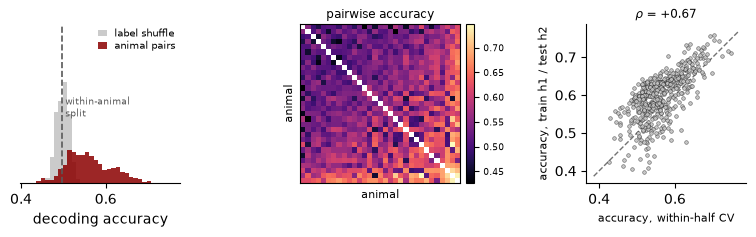

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL * 1.25, PANEL * 1.15))

# a -- the accuracies against the two references
ax = axes[0]
bins = np.linspace(min(chance.min(), acc.min()) - .01, acc.max() + .01, 34)
ax.hist(chance, bins=bins, color=NULLC, alpha=.8, label="label shuffle")
ax.hist(acc, bins=bins, color=DATAC, alpha=.85, label="animal pairs")
ax.axvline(floor.mean(), color="0.35", lw=1.2, ls="--")
ax.set(xlabel="decoding accuracy", yticks=[])
ax.set_ylim(0, ax.get_ylim()[1] * 1.5)
ax.text(floor.mean(), ax.get_ylim()[1] * .55, " within-animal\n split", fontsize=6.5,
        color="0.35", va="top", ha="left")
ax.legend(frameon=False, fontsize=7, loc="upper right", handlelength=.9,
          labelspacing=.2, borderaxespad=.1)
ax.set_box_aspect(1); sns.despine(ax=ax, left=True)

# b -- the matrix, animals ordered by how identifiable they are
ax = axes[1]
order = np.argsort(dec)
M = A[order][:, order].astype(float).copy()
np.fill_diagonal(M, np.nan)
cmap = plt.get_cmap("magma").copy(); cmap.set_bad("white")
im = ax.imshow(M, cmap=cmap, clim=(acc.min(), acc.max()))
ax.set(xticks=[], yticks=[])
ax.set_xlabel("animal", fontsize=8); ax.set_ylabel("animal", fontsize=8)
ax.set_title("pairwise accuracy", fontsize=8.5, pad=4)
cb = plt.colorbar(im, ax=ax, fraction=.046, pad=.03); cb.ax.tick_params(labelsize=6.5)
ax.set_box_aspect(1)

# c -- within-half vs across-half: the reliability check
ax = axes[2]
ax.scatter(acc, xv, s=7, color="0.75", edgecolor="black", linewidths=.25, alpha=.9)
lim = [min(acc.min(), xv.min()) - .01, max(acc.max(), xv.max()) + .01]
ax.plot(lim, lim, ls="--", lw=1, color="0.45", zorder=0)
ax.set_xlabel("accuracy, within-half CV", fontsize=8)
ax.set_ylabel("accuracy, train h1 / test h2", fontsize=8)
ax.set_title(rf"$\rho$ = {stats.spearmanr(acc, xv)[0]:+.2f}", fontsize=8.5, pad=4)
ax.set_box_aspect(1); sns.despine(ax=ax)

fig.tight_layout(w_pad=1.6)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"animal_decoding.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## What this does and does not show

Single head-direction tuning curves carry information about which recording they came from, at
0.563 on average against a floor of 0.498, rising to 0.597 when the decoder is trained and tested
on independent estimates of the same neurons. The signal is real and it is not rate alone.

What it cannot show is that this is about the *animal*. With one session per animal, a
recording-level difference and an animal-level difference are the same number. The honest
summary is that HD recordings are individually identifiable from single neurons, and that
separating the biology from the electrophysiology would need an animal recorded twice.